In [2]:
from google.colab import files
import numpy as np
import pandas as pd

# Most of the code and algorithms used here were done with the help of chatbots because I was new to this and was mainly using them for learning. I used them to understand how things work and to learn the implementation. This will also help me when I work with other datasets in the future. So, I hope you understand that I mainly used them for learning purposes.(written by chatgpt 😂🤡)

In [4]:
upl=files.upload()

Saving Country-data.csv to Country-data.csv


In [60]:
df=pd.read_csv("Country-data.csv")

In [61]:
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [63]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [64]:
df.isna().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

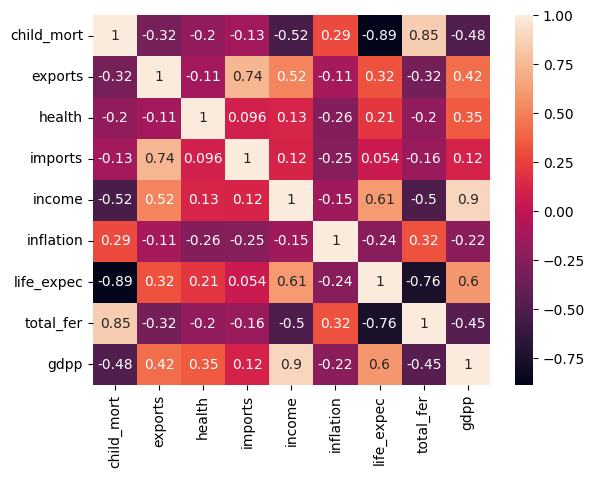

In [67]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

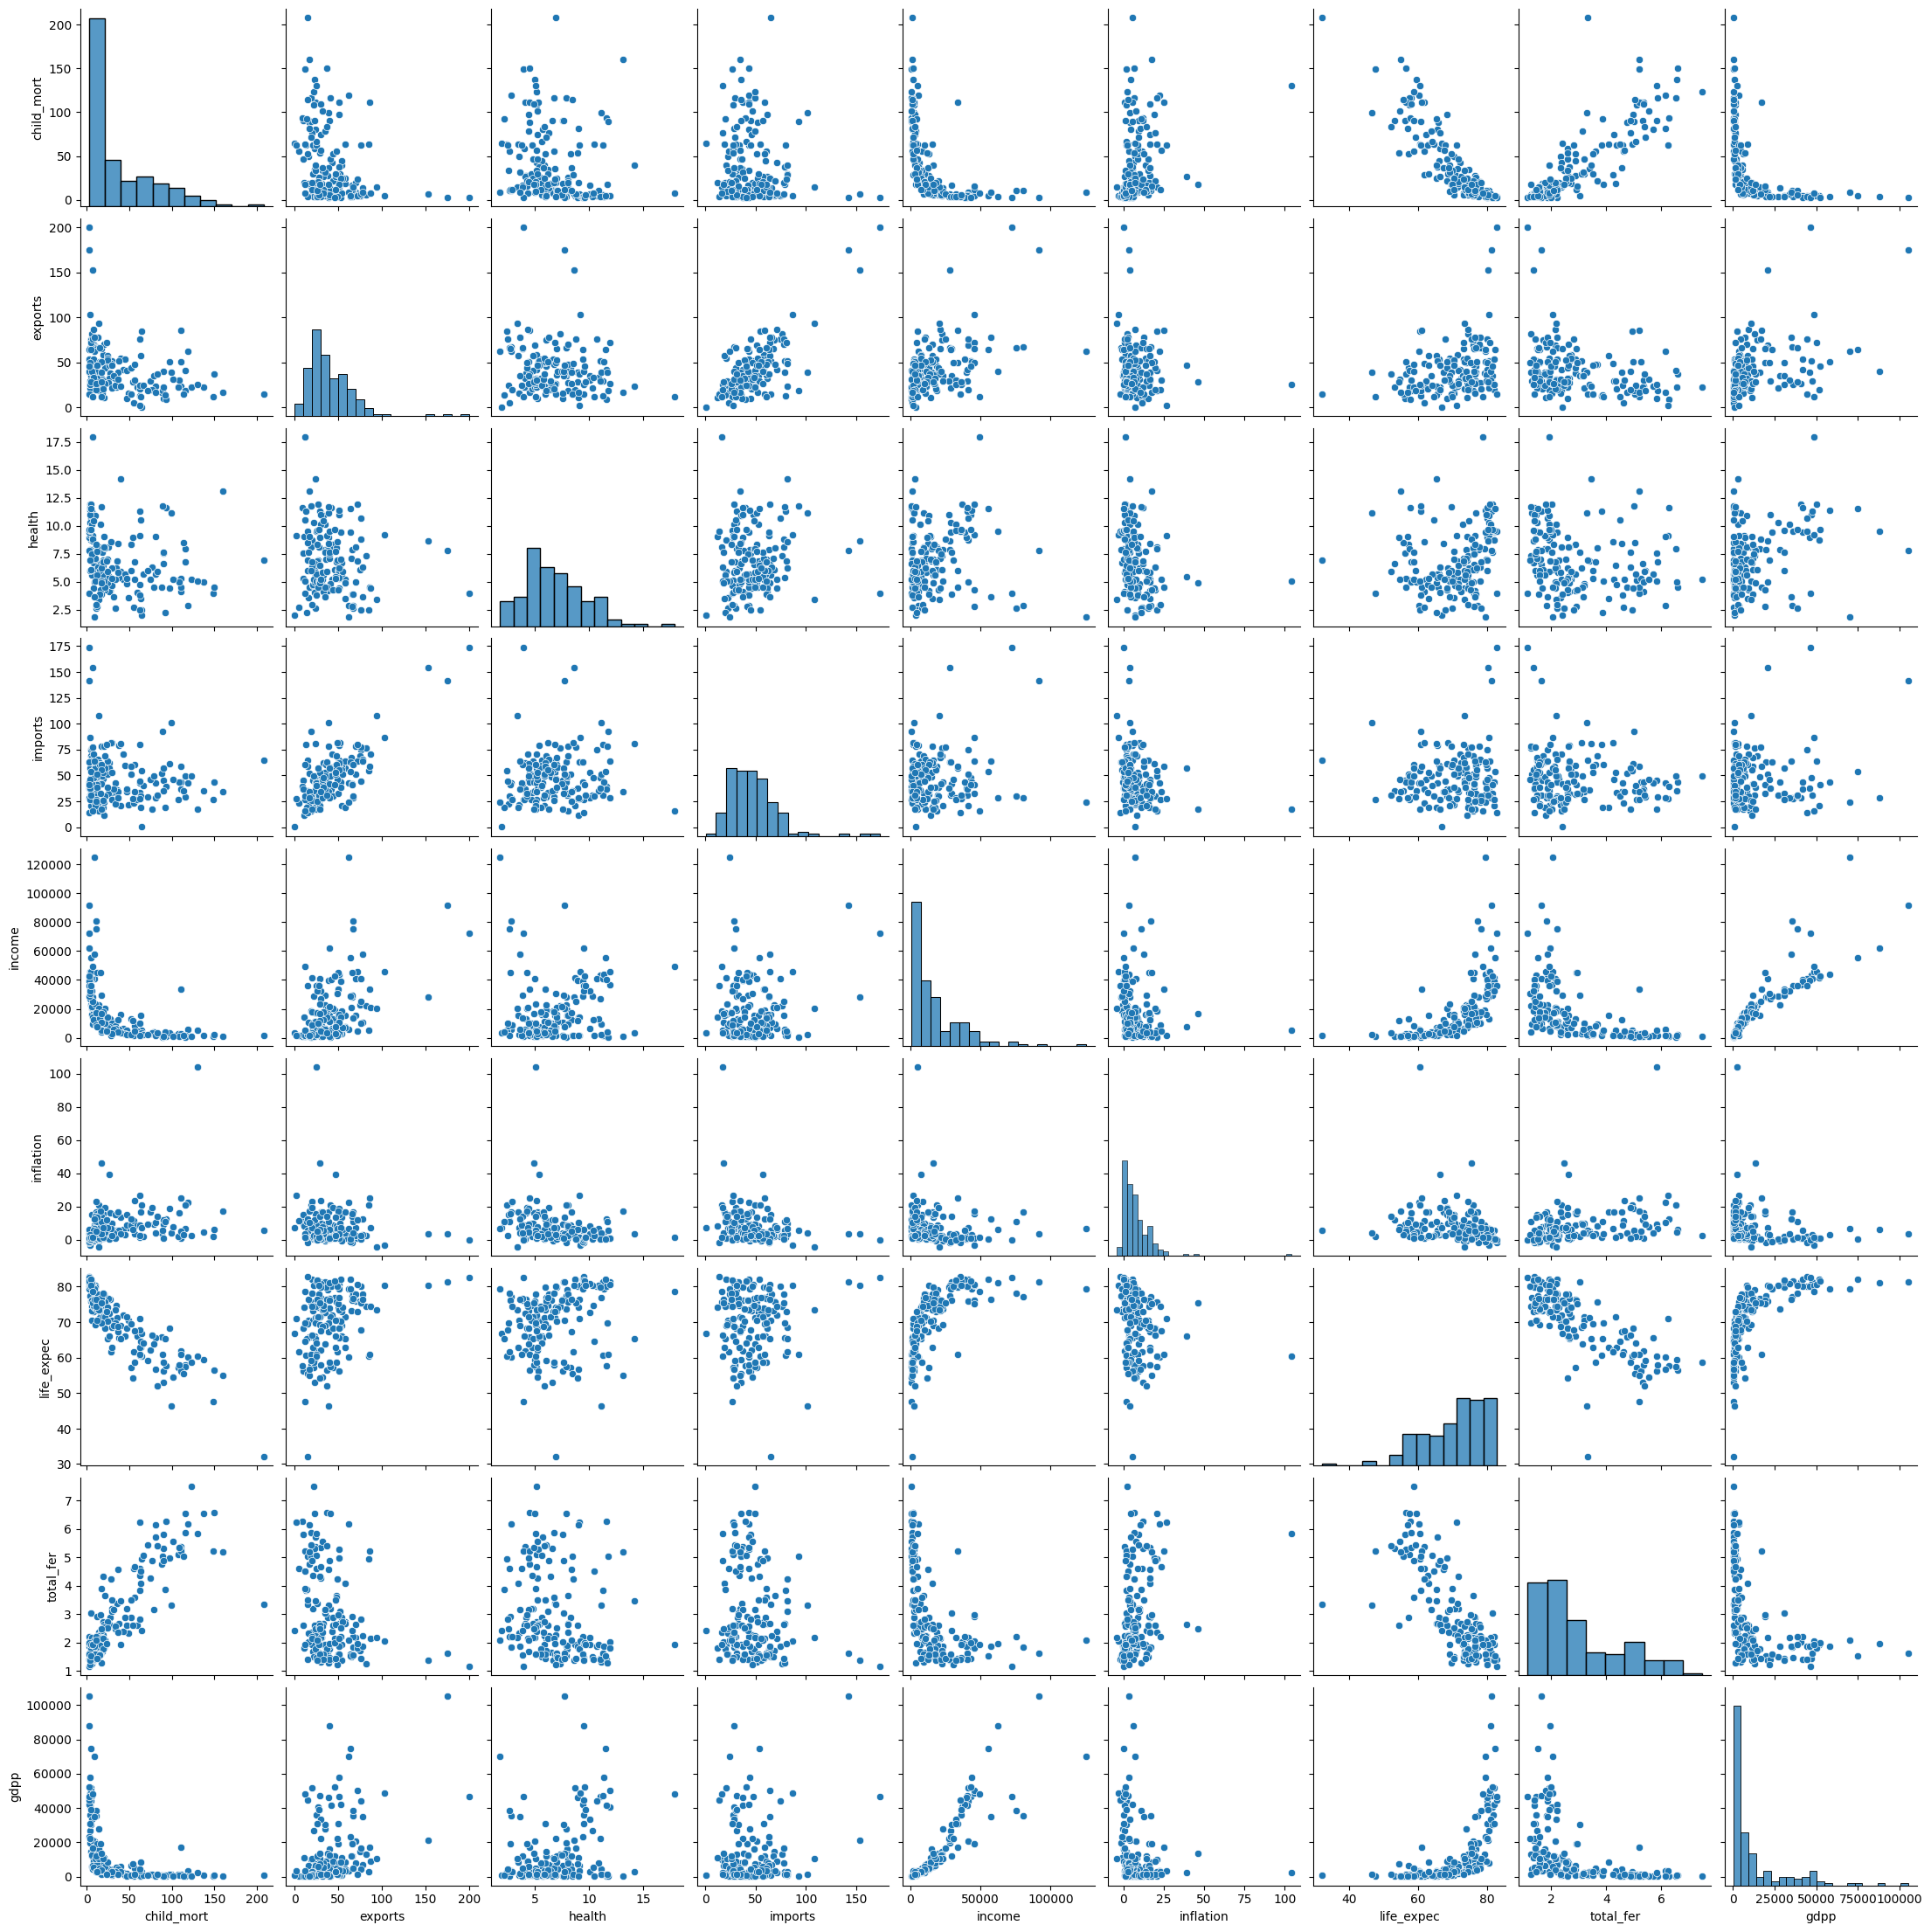

In [68]:
sns.pairplot(df)

In [69]:
from sklearn.preprocessing import StandardScaler

In [70]:
scale=StandardScaler()

In [71]:
x_scaled=df.drop("country",axis=1)

In [72]:
x_scaled=scale.fit_transform(x_scaled)

In [73]:
from sklearn.decomposition import PCA

variance_captured = []
components_range = range(1, 10)

for n in components_range:
    pca = PCA(n_components=n)
    pca.fit(x_scaled)
    variance_captured.append(pca.explained_variance_ratio_.sum())
    print(f"n_components={n} -> cumulative variance = {variance_captured[-1]:.3f}")

n_components=1 -> cumulative variance = 0.460
n_components=2 -> cumulative variance = 0.631
n_components=3 -> cumulative variance = 0.761
n_components=4 -> cumulative variance = 0.872
n_components=5 -> cumulative variance = 0.945
n_components=6 -> cumulative variance = 0.970
n_components=7 -> cumulative variance = 0.983
n_components=8 -> cumulative variance = 0.993
n_components=9 -> cumulative variance = 1.000


In [74]:
pca_x=PCA(n_components=5)
x_train=pca_x.fit_transform(x_scaled)

In [75]:

from sklearn.cluster import KMeans

In [76]:
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(x_train)
    wcss.append(km.inertia_)

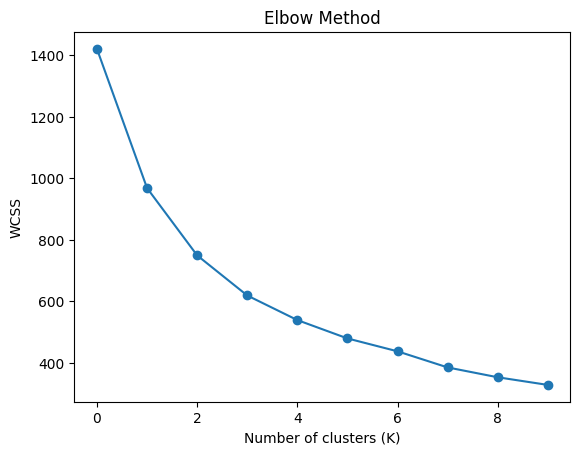

In [77]:
plt.plot(wcss, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [78]:
from sklearn.metrics import silhouette_score



In [79]:
sil_scores = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(x_train)
    score = silhouette_score(x_train, labels)
    sil_scores.append(score)
    print(f"K={k} -> silhouette = {score:.3f}")



K=2 -> silhouette = 0.304
K=3 -> silhouette = 0.308
K=4 -> silhouette = 0.329
K=5 -> silhouette = 0.330
K=6 -> silhouette = 0.256
K=7 -> silhouette = 0.226
K=8 -> silhouette = 0.258
K=9 -> silhouette = 0.236
K=10 -> silhouette = 0.245


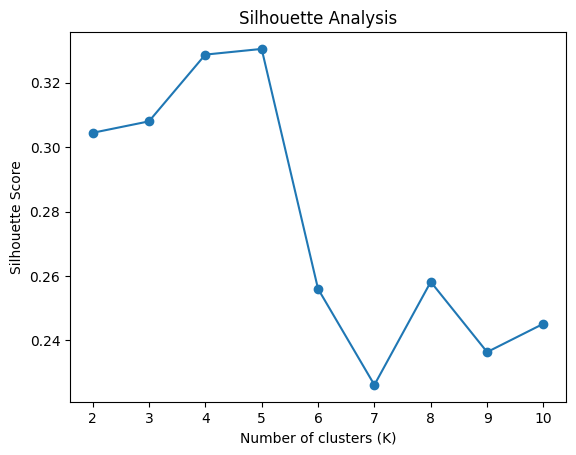

In [80]:
plt.plot(K, sil_scores, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

In [81]:
x_train

array([[-2.91302459e+00,  9.56205755e-02, -7.18118495e-01,
         1.00525464e+00, -1.58310044e-01],
       [ 4.29911330e-01, -5.88155666e-01, -3.33485505e-01,
        -1.16105859e+00,  1.74677321e-01],
       [-2.85225077e-01, -4.55174413e-01,  1.22150481e+00,
        -8.68114503e-01,  1.56474647e-01],
       [-2.93242265e+00,  1.69555507e+00,  1.52504374e+00,
         8.39625014e-01, -2.73208934e-01],
       [ 1.03357587e+00,  1.36658709e-01, -2.25720917e-01,
        -8.47062687e-01, -1.93006961e-01],
       [ 2.24072616e-02, -1.77918658e+00,  8.69997116e-01,
        -3.69668667e-02,  9.81056507e-01],
       [-1.01583737e-01, -5.68251724e-01,  2.42091816e-01,
        -1.46626576e+00, -5.59924282e-02],
       [ 2.34216461e+00, -1.98845915e+00,  1.90344188e-01,
         1.10503778e+00, -7.31192330e-01],
       [ 2.97376366e+00, -7.34688659e-01, -5.19766356e-01,
         1.20544210e+00,  8.35797058e-02],
       [-1.81486997e-01, -4.02865873e-01,  8.67458743e-01,
        -4.38772983e-01

In [82]:
for k in [4, 5]:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    df[f'cluster_k{k}'] = km.fit_predict(x_train)

    print(f"\n========== K = {k} ==========")

    print(
        df.groupby(f'cluster_k{k}')[
            ['child_mort', 'income', 'life_expec', 'gdpp']
        ].mean()
    )

    print("\nNumber of countries:")
    print(df[f'cluster_k{k}'].value_counts().sort_index())


========== K = 4 ==========
            child_mort        income  life_expec          gdpp
cluster_k4                                                    
0            21.913483  12969.325843   72.693258   6885.528090
1             4.953333  45250.000000   80.376667  43333.333333
2            95.106667   3539.844444   59.055556   1766.711111
3             4.133333  64033.333333   81.433333  57566.666667

Number of countries:
cluster_k4
0    89
1    30
2    45
3     3
Name: count, dtype: int64

========== K = 5 ==========
            child_mort        income  life_expec          gdpp
cluster_k5                                                    
0            20.889535  13076.162791   73.006977   6988.069767
1             4.953333  45250.000000   80.376667  43333.333333
2            91.565957   3911.978723   59.321277   1893.829787
3             4.133333  64033.333333   81.433333  57566.666667
4           130.000000   5150.000000   60.500000   2330.000000

Number of countries:
cluster_k5

In [83]:
labels = km.fit_predict(x_train)

df['cluster'] = labels

In [84]:
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_k4,cluster_k5,cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2,2,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0,0,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0,0,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2,2,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,0,0,0
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,0,0,0
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,0,0,0
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,2,2,2


In [85]:
from sklearn.cluster import AgglomerativeClustering

In [86]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp', 'cluster_k4',
       'cluster_k5', 'cluster'],
      dtype='object')

In [87]:
df2=df.copy()

In [88]:
df2.drop(columns=(['cluster_k4',
       'cluster_k5', 'cluster',]))

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [89]:
x_df2=df.drop(columns=(['country']))

In [90]:
shout=[]
for i in range(2,10):

  ac=AgglomerativeClustering(n_clusters=i,linkage='ward')
  labels= ac.fit_predict(x_train)
  score = silhouette_score(x_train, labels)

  shout.append(score)


  print(f"K={i} -> silhouette = {score:.3f}")


K=2 -> silhouette = 0.329
K=3 -> silhouette = 0.304
K=4 -> silhouette = 0.314
K=5 -> silhouette = 0.319
K=6 -> silhouette = 0.334
K=7 -> silhouette = 0.266
K=8 -> silhouette = 0.236
K=9 -> silhouette = 0.253


In [91]:
for k in [2,3,4,5,6]:

    ac=AgglomerativeClustering(n_clusters=k,linkage='ward')
    df2[f'cluster_k{k}'] = ac.fit_predict(x_train)

    print(f"\n========== K = {k} ==========")

    print(
        df2.groupby(f'cluster_k{k}')[
            ['child_mort', 'income', 'life_expec', 'gdpp']
        ].mean()
    )

    print("\nNumber of countries:")
    print(df2[f'cluster_k{k}'].value_counts().sort_index())


========== K = 2 ==========
            child_mort        income  life_expec          gdpp
cluster_k2                                                    
0            16.148718  22812.222222   75.274359  17688.239316
1            90.034000   3882.660000   59.514000   1909.800000

Number of countries:
cluster_k2
0    117
1     50
Name: count, dtype: int64

========== K = 3 ==========
            child_mort        income  life_expec          gdpp
cluster_k3                                                    
0             6.003030  48133.333333   79.939394  43551.515152
1            90.034000   3882.660000   59.514000   1909.800000
2            20.134524  12864.642857   73.441667   7527.666667

Number of countries:
cluster_k3
0    33
1    50
2    84
Name: count, dtype: int64

========== K = 4 ==========
            child_mort        income  life_expec          gdpp
cluster_k4                                                    
0            90.034000   3882.660000   59.514000   1909.8000

In [92]:
from sklearn.cluster import DBSCAN

In [93]:


results = []

for min_samples in [3, 4, 5, 6, 7, 8, 10]:

    for eps in np.arange(0.2, 1.1, 0.1):

        db = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = db.fit_predict(x_train)


        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)


        n_noise = np.sum(labels == -1)


        if n_clusters >= 2:

            mask = labels != -1


            if len(set(labels[mask])) >= 2:

                score = silhouette_score(
                    x_train[mask],
                    labels[mask]
                )

                results.append(
                    [eps, min_samples, n_clusters, n_noise, score]
                )

In [94]:
results_df = pd.DataFrame(
    results,
    columns=[
        'eps',
        'min_samples',
        'n_clusters',
        'n_noise',
        'silhouette'
    ]
)

In [95]:
results_df.sort_values(
    by='silhouette',
    ascending=False
).head(10)

,eps,min_samples,n_clusters,n_noise,silhouette
0,0.4,3,2,159,0.812417
7,0.6,4,4,143,0.586774
1,0.5,3,5,145,0.550400
17,0.8,6,2,127,0.549019
12,0.7,5,4,125,0.528773
11,0.6,5,2,153,0.502888
20,0.9,7,3,94,0.460718
22,0.9,8,2,103,0.460412
24,1.0,10,2,92,0.452875
21,1.0,7,3,58,0.432720
